### **Universidad Autónoma de Guadalajara**
#### Aprendizaje Automatizado para la Gestión de Datos Masivos
#### TAREA 07
##### **ANAYANSI CRISTINA HERNÁNDEZ ABREGO**

**Julio/2026**

Importar las librerías a utlizar 

In [ ]:
import pandas as pd # leer datos
import numpy as np # manipular datos numéricos
import matplotlib.pyplot as plt # Crear gráficos

from mlxtend.frequent_patterns import apriori # Algoritmo Apriori
from mlxtend.frequent_patterns import association_rules # Crear reglas de asociación

Cargar y leer datos

In [ ]:
bread_basket_data = pd.read_csv('./data/BreadBasket_DMS.csv')

bread_basket_data.head(10)

,Date,Time,Transaction,Item
0,2016-10-30,09:58:11,1,Bread
1,2016-10-30,10:05:34,2,Scandinavian
2,2016-10-30,10:05:34,2,Scandinavian
3,2016-10-30,10:07:57,3,Hot chocolate
4,2016-10-30,10:07:57,3,Jam
5,2016-10-30,10:07:57,3,Cookies
6,2016-10-30,10:08:41,4,Muffin
7,2016-10-30,10:13:03,5,Coffee
8,2016-10-30,10:13:03,5,Pastry
9,2016-10-30,10:13:03,5,Bread


Dimensiones del dataset

In [4]:
bread_basket_data.shape

(21293, 4)

Verificar si existen valores faltantes

In [5]:
bread_basket_data.loc[bread_basket_data['Item'] == 'NONE'].count()

Date           786
Time           786
Transaction    786
Item           786
dtype: int64

Remover valores faltantes

In [ ]:
bread_basket_data = bread_basket_data.drop(
    bread_basket_data.loc[bread_basket_data['Item'] == 'NONE'].index)

Verificar nuevamente la existencia de valores faltantes

In [7]:
bread_basket_data.loc[bread_basket_data['Item'] == 'NONE'].count()

Date           0
Time           0
Transaction    0
Item           0
dtype: int64

Verificar las dimensiones del dataset después de eliminar los valores faltantes

In [8]:
bread_basket_data.shape

(20507, 4)

Mostrar valores únicos en la variable item

In [9]:
bread_basket_data['Item'].unique()

<ArrowStringArray>
[                        'Bread',                  'Scandinavian',
                 'Hot chocolate',                           'Jam',
                       'Cookies',                        'Muffin',
                        'Coffee',                        'Pastry',
                     'Medialuna',                           'Tea',
                       'Tartine',                        'Basket',
                 'Mineral water',                    'Farm House',
                         'Fudge',                         'Juice',
        'Ella's Kitchen Pouches',              'Victorian Sponge',
                      'Frittata',             'Hearty & Seasonal',
                          'Soup',            'Pick and Mix Bowls',
                     'Smoothies',                          'Cake',
                'Mighty Protein',                  'Chicken sand',
                          'Coke',              'My-5 Fruit Shoot',
                      'Focaccia',          

Calcular la frecuencia de cada item

In [ ]:
basket_items = {}

for item in bread_basket_data['Item']:
    if item in basket_items:
        basket_items[item] = basket_items[item] + 1
    else:
        basket_items[item] = 1


In [11]:
basket_items

{'Bread': 3325,
 'Scandinavian': 277,
 'Hot chocolate': 590,
 'Jam': 149,
 'Cookies': 540,
 'Muffin': 370,
 'Coffee': 5471,
 'Pastry': 856,
 'Medialuna': 616,
 'Tea': 1435,
 'Tartine': 47,
 'Basket': 6,
 'Mineral water': 136,
 'Farm House': 374,
 'Fudge': 159,
 'Juice': 369,
 "Ella's Kitchen Pouches": 17,
 'Victorian Sponge': 7,
 'Frittata': 81,
 'Hearty & Seasonal': 107,
 'Soup': 342,
 'Pick and Mix Bowls': 12,
 'Smoothies': 77,
 'Cake': 1025,
 'Mighty Protein': 11,
 'Chicken sand': 1,
 'Coke': 185,
 'My-5 Fruit Shoot': 18,
 'Focaccia': 54,
 'Sandwich': 771,
 'Alfajores': 369,
 'Eggs': 28,
 'Brownie': 379,
 'Dulce de Leche': 13,
 'Honey': 6,
 'The BART': 1,
 'Granola': 28,
 'Fairy Doors': 2,
 'Empanadas': 7,
 'Keeping It Local': 63,
 'Art Tray': 38,
 'Bowl Nic Pitt': 2,
 'Bread Pudding': 4,
 'Adjustment': 1,
 'Truffles': 193,
 'Chimichurri Oil': 2,
 'Bacon': 1,
 'Spread': 2,
 'Kids biscuit': 12,
 'Siblings': 2,
 'Caramel bites': 3,
 'Jammie Dodgers': 125,
 'Tiffin': 146,
 'Olum & pole

In [ ]:

item_names = []
item_frequencies = []

for key, val in basket_items.items():
    item_names.append(key)
    item_frequencies.append(val)


In [ ]:

items_table = pd.DataFrame({'Names': item_names,
                            'Frequencies': item_frequencies})

items_table


,Names,Frequencies
0,Bread,3325
1,Scandinavian,277
2,Hot chocolate,590
3,Jam,149
4,Cookies,540
...,...,...
89,Gift voucher,1
90,Cherry me Dried fruit,3
91,Mortimer,5
92,Raw bars,1


Graficar en una Plotting Bar los items vs frequency

<Axes: xlabel='Names'>

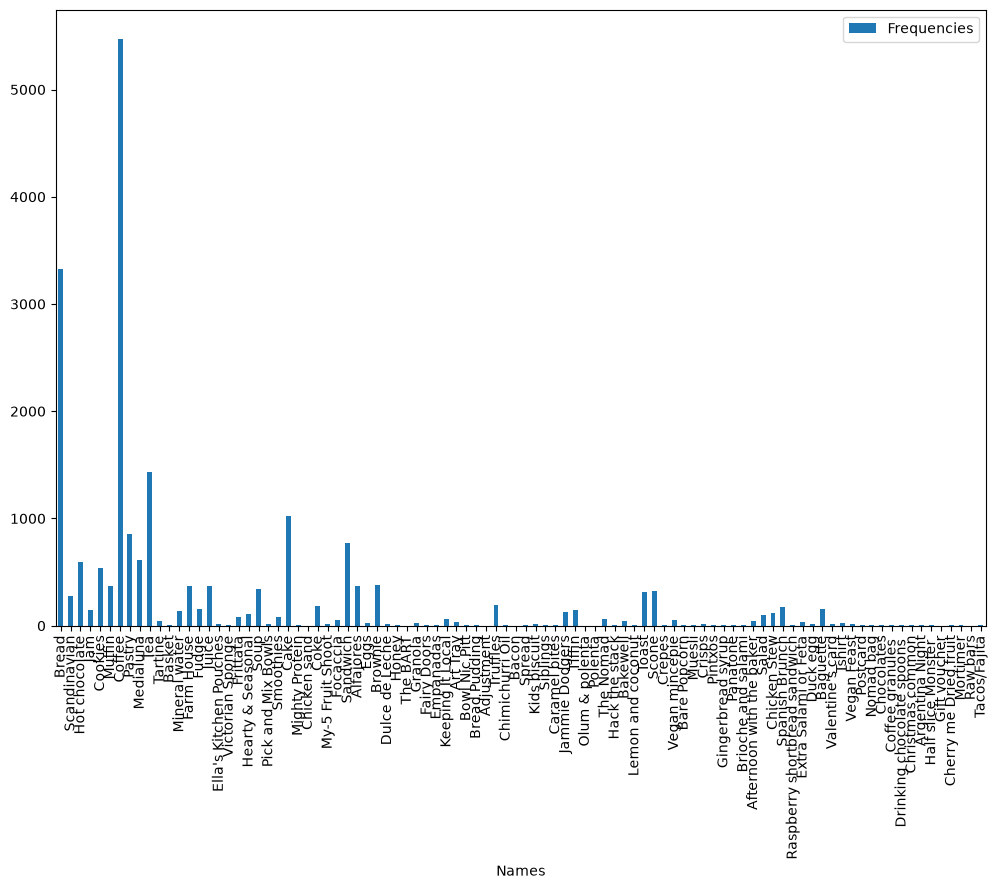

In [14]:
items_table.sort_values('Frequencies', ascending=False).head()
items_table.plot.bar(y='Frequencies', x='Names', figsize=(12, 8))

<Axes: xlabel='Names'>

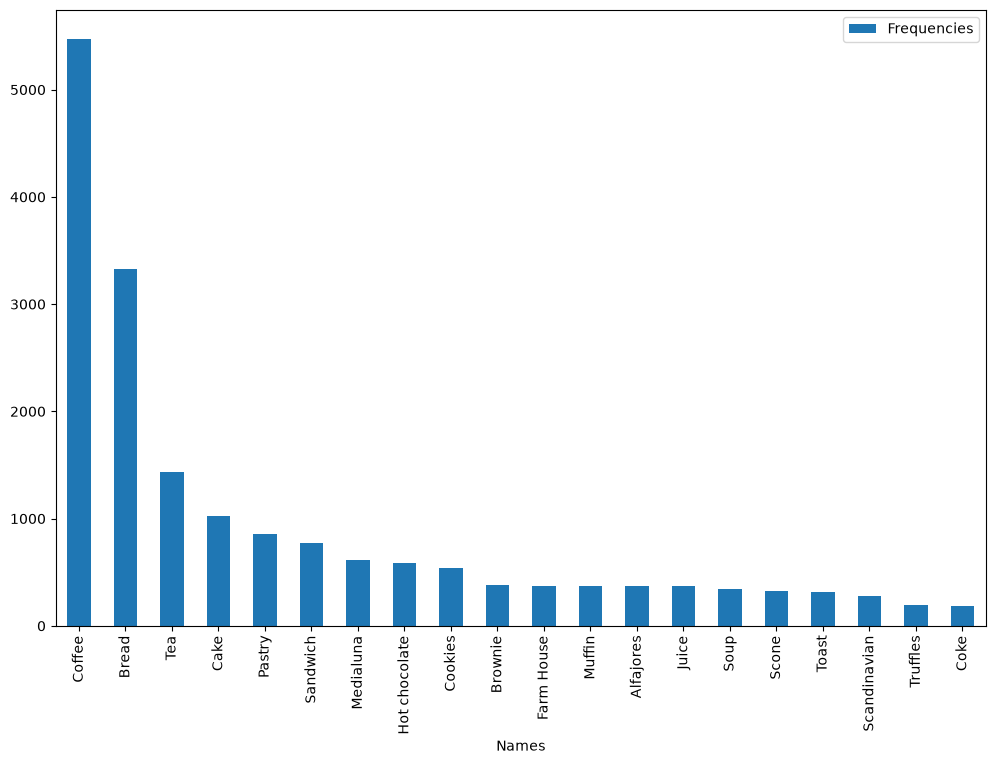

In [ ]:

items_table.sort_values('Frequencies', ascending=False).head(20).\
    plot.bar(y='Frequencies', x='Names', figsize=(12, 8))


Resumen estadístico del dataset

In [17]:
bread_basket_data['Transaction'].describe()

count    20507.000000
mean      4976.202370
std       2796.203001
min          1.000000
25%       2552.000000
50%       5137.000000
75%       7357.000000
max       9684.000000
Name: Transaction, dtype: float64

Agrupar los item con el mismo id transaction

In [ ]:

bread_basket_data = bread_basket_data.groupby('Transaction').agg(','.join).reset_index()

bread_basket_data = bread_basket_data.drop(['Date', 'Time'], axis=1)
bread_basket_data.head(10)


,Transaction,Item
0,1,Bread
1,2,"Scandinavian,Scandinavian"
2,3,"Hot chocolate,Jam,Cookies"
3,4,Muffin
4,5,"Coffee,Pastry,Bread"
5,6,"Medialuna,Pastry,Muffin"
6,7,"Medialuna,Pastry,Coffee,Tea"
7,8,"Pastry,Bread"
8,9,"Bread,Muffin"
9,10,"Scandinavian,Medialuna"


In [19]:
bread_basket_data.shape

(9465, 2)

Mostrar el conjunto de items

In [21]:

items_data = bread_basket_data['Item']

items_data.head(10)



0                          Bread
1      Scandinavian,Scandinavian
2      Hot chocolate,Jam,Cookies
3                         Muffin
4            Coffee,Pastry,Bread
5        Medialuna,Pastry,Muffin
6    Medialuna,Pastry,Coffee,Tea
7                   Pastry,Bread
8                   Bread,Muffin
9         Scandinavian,Medialuna
Name: Item, dtype: str

Convertir en una lista y convertir cada item en una lista

In [22]:
items_list = [item.split(',') for item in items_data]

items_list_df = pd.DataFrame({'Items': items_list})

items_list_df.head(10)

,Items
0,[Bread]
1,"[Scandinavian, Scandinavian]"
2,"[Hot chocolate, Jam, Cookies]"
3,[Muffin]
4,"[Coffee, Pastry, Bread]"
5,"[Medialuna, Pastry, Muffin]"
6,"[Medialuna, Pastry, Coffee, Tea]"
7,"[Pastry, Bread]"
8,"[Bread, Muffin]"
9,"[Scandinavian, Medialuna]"


### Minería de reglas de asociación

In [23]:
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori

transencoder = TransactionEncoder()

transencoder_array = transencoder.fit(items_list).transform(items_list)

In [24]:

encoded_df = pd.DataFrame(transencoder_array, columns=transencoder.columns_)

encoded_df.head(10)

,Adjustment,Afternoon with the baker,Alfajores,Argentina Night,Art Tray,Bacon,Baguette,Bakewell,Bare Popcorn,Basket,...,The BART,The Nomad,Tiffin,Toast,Truffles,Tshirt,Valentine's card,Vegan Feast,Vegan mincepie,Victorian Sponge
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
6,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
8,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
9,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


Soporte de cada conjunto de items

In [ ]:


item_support_df = apriori(encoded_df, min_support=0.01, use_colnames=True)

item_support_df.shape


(61, 2)

In [26]:
item_support_df.sample(10)

,support,itemsets
8,0.054411,frozenset({Cookies})
3,0.040042,frozenset({Brownie})
51,0.038246,"frozenset({Coffee, Sandwich})"
37,0.016904,"frozenset({Bread, Medialuna})"
35,0.014474,"frozenset({Cookies, Bread})"
56,0.023666,"frozenset({Toast, Coffee})"
59,0.011199,"frozenset({Coffee, Bread, Pastry})"
41,0.019651,"frozenset({Brownie, Coffee})"
60,0.010037,"frozenset({Tea, Coffee, Cake})"
29,0.020285,frozenset({Truffles})


Reglas de asociación

In [27]:
from mlxtend.frequent_patterns import association_rules

rules = association_rules(item_support_df, 
                          metric='confidence', min_threshold=0.1)

rules.shape

(44, 14)

In [28]:
rules.sample(10)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
33,frozenset({Sandwich}),frozenset({Tea}),0.071844,0.142631,0.014369,0.200000,1.402222,1.0,0.004122,1.071712,0.309050,0.071806,0.066913,0.150370
15,frozenset({Hot chocolate}),frozenset({Cake}),0.058320,0.103856,0.011410,0.195652,1.883874,1.0,0.005354,1.114125,0.498236,0.075683,0.102434,0.152760
10,frozenset({Sandwich}),frozenset({Bread}),0.071844,0.327205,0.017010,0.236765,0.723596,1.0,-0.006498,0.881503,-0.291561,0.044524,-0.134426,0.144375
6,frozenset({Cookies}),frozenset({Bread}),0.054411,0.327205,0.014474,0.266019,0.813004,1.0,-0.003329,0.916638,-0.195651,0.039424,-0.090943,0.155128
22,frozenset({Medialuna}),frozenset({Coffee}),0.061807,0.478394,0.035182,0.569231,1.189878,1.0,0.005614,1.210871,0.170091,0.069665,0.174148,0.321387
13,frozenset({Coffee}),frozenset({Cake}),0.478394,0.103856,0.054728,0.114399,1.101515,1.0,0.005044,1.011905,0.176684,0.103745,0.011765,0.320679
38,"frozenset({Bread, Pastry})",frozenset({Coffee}),0.029160,0.478394,0.011199,0.384058,0.802807,1.0,-0.002751,0.846843,-0.201920,0.022563,-0.180857,0.203734
23,frozenset({Muffin}),frozenset({Coffee}),0.038457,0.478394,0.018806,0.489011,1.022193,1.0,0.000408,1.020777,0.022579,0.037760,0.020354,0.264161
16,frozenset({Cake}),frozenset({Hot chocolate}),0.103856,0.058320,0.011410,0.109868,1.883874,1.0,0.005354,1.057910,0.523553,0.075683,0.054740,0.152760
21,frozenset({Juice}),frozenset({Coffee}),0.038563,0.478394,0.020602,0.534247,1.116750,1.0,0.002154,1.119919,0.108738,0.041507,0.107078,0.288656


In [29]:
rules.sort_values('confidence', ascending=False).head(10)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
31,frozenset({Toast}),frozenset({Coffee}),0.033597,0.478394,0.023666,0.704403,1.472431,1.0,0.007593,1.764582,0.332006,0.048464,0.433293,0.376936
28,frozenset({Spanish Brunch}),frozenset({Coffee}),0.018172,0.478394,0.010882,0.598837,1.251766,1.0,0.002189,1.300235,0.204851,0.022406,0.230908,0.310792
22,frozenset({Medialuna}),frozenset({Coffee}),0.061807,0.478394,0.035182,0.569231,1.189878,1.0,0.005614,1.210871,0.170091,0.069665,0.174148,0.321387
24,frozenset({Pastry}),frozenset({Coffee}),0.086107,0.478394,0.047544,0.552147,1.154168,1.0,0.006351,1.164682,0.146161,0.091968,0.141396,0.325764
1,frozenset({Alfajores}),frozenset({Coffee}),0.036344,0.478394,0.019651,0.540698,1.130235,1.0,0.002264,1.135648,0.119574,0.039693,0.119446,0.290888
21,frozenset({Juice}),frozenset({Coffee}),0.038563,0.478394,0.020602,0.534247,1.116750,1.0,0.002154,1.119919,0.108738,0.041507,0.107078,0.288656
25,frozenset({Sandwich}),frozenset({Coffee}),0.071844,0.478394,0.038246,0.532353,1.112792,1.0,0.003877,1.115384,0.109205,0.074701,0.103448,0.306150
14,frozenset({Cake}),frozenset({Coffee}),0.103856,0.478394,0.054728,0.526958,1.101515,1.0,0.005044,1.102664,0.102840,0.103745,0.093105,0.320679
26,frozenset({Scone}),frozenset({Coffee}),0.034548,0.478394,0.018067,0.522936,1.093107,1.0,0.001539,1.093366,0.088224,0.036507,0.085393,0.280350
19,frozenset({Cookies}),frozenset({Coffee}),0.054411,0.478394,0.028209,0.518447,1.083723,1.0,0.002179,1.083174,0.081700,0.055905,0.076787,0.288707


In [30]:
rules["antecedent_len"] = rules["antecedents"].apply(lambda x: len(x))

rules.sample(5)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski,antecedent_len
6,frozenset({Cookies}),frozenset({Bread}),0.054411,0.327205,0.014474,0.266019,0.813004,1.0,-0.003329,0.916638,-0.195651,0.039424,-0.090943,0.155128,1
35,"frozenset({Bread, Cake})",frozenset({Coffee}),0.023349,0.478394,0.010037,0.429864,0.898557,1.0,-0.001133,0.914880,-0.103617,0.020413,-0.093039,0.225422,2
29,frozenset({Tea}),frozenset({Coffee}),0.142631,0.478394,0.049868,0.349630,0.730840,1.0,-0.018366,0.802014,-0.300482,0.087310,-0.246862,0.226935,1
40,frozenset({Pastry}),"frozenset({Bread, Coffee})",0.086107,0.090016,0.011199,0.130061,1.444872,1.0,0.003448,1.046033,0.336907,0.067905,0.044007,0.127237,1
39,"frozenset({Coffee, Pastry})",frozenset({Bread}),0.047544,0.327205,0.011199,0.235556,0.719901,1.0,-0.004357,0.880109,-0.290026,0.030805,-0.136223,0.134891,2


Seleccionar antecedentes donde la frecuencia de item es Juice

In [31]:
rules[rules['antecedents'] == {'Juice'}]

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski,antecedent_len
21,frozenset({Juice}),frozenset({Coffee}),0.038563,0.478394,0.020602,0.534247,1.11675,1.0,0.002154,1.119919,0.108738,0.041507,0.107078,0.288656,1


Seleccione los antecedentes donde la frecuencia de los artículos sea Pastel

In [32]:
rules[rules['antecedents'] == {'Cake'}]

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski,antecedent_len
3,frozenset({Cake}),frozenset({Bread}),0.103856,0.327205,0.023349,0.224822,0.687097,1.0,-0.010633,0.867923,-0.336947,0.057269,-0.152177,0.148091,1
14,frozenset({Cake}),frozenset({Coffee}),0.103856,0.478394,0.054728,0.526958,1.101515,1.0,0.005044,1.102664,0.102840,0.103745,0.093105,0.320679,1
16,frozenset({Cake}),frozenset({Hot chocolate}),0.103856,0.058320,0.011410,0.109868,1.883874,1.0,0.005354,1.057910,0.523553,0.075683,0.054740,0.152760,1
18,frozenset({Cake}),frozenset({Tea}),0.103856,0.142631,0.023772,0.228891,1.604781,1.0,0.008959,1.111865,0.420538,0.106736,0.100611,0.197779,1


In [33]:
rules[rules['antecedents'] == {'Sandwich'}]

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski,antecedent_len
10,frozenset({Sandwich}),frozenset({Bread}),0.071844,0.327205,0.017010,0.236765,0.723596,1.0,-0.006498,0.881503,-0.291561,0.044524,-0.134426,0.144375,1
25,frozenset({Sandwich}),frozenset({Coffee}),0.071844,0.478394,0.038246,0.532353,1.112792,1.0,0.003877,1.115384,0.109205,0.074701,0.103448,0.306150,1
33,frozenset({Sandwich}),frozenset({Tea}),0.071844,0.142631,0.014369,0.200000,1.402222,1.0,0.004122,1.071712,0.309050,0.071806,0.066913,0.150370,1


In [34]:
rules[rules['antecedents'] == {'Coffee'}]

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski,antecedent_len
5,frozenset({Coffee}),frozenset({Bread}),0.478394,0.327205,0.090016,0.188163,0.575059,1.0,-0.066517,0.828731,-0.586210,0.125794,-0.206665,0.231634,1
13,frozenset({Coffee}),frozenset({Cake}),0.478394,0.103856,0.054728,0.114399,1.101515,1.0,0.005044,1.011905,0.176684,0.103745,0.011765,0.320679,1
30,frozenset({Coffee}),frozenset({Tea}),0.478394,0.142631,0.049868,0.104240,0.730840,1.0,-0.018366,0.957142,-0.413856,0.087310,-0.044777,0.226935,1
